# 2D Structure Function / CROCO Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D CROCO data.

$\textbf{General procedure}:$


1 -  Load a croco dataset, the dataset can be accessed https://doi.org/10.1175/JPO-D-18-0029.1

2 -  Format dataset to match pyturbo_sf inputs

3 -  Calculate second-order 2D longitudinal structure function as a function of separation distances

4 -  Plot the 2D SF with errors and number of bootstraps

5 -  Calculate Isotropic second-order longitudinal & Transverse structure function and their associated errors

6 -  Plot Isotropic Longitudinal and transverse SFs with isotropy and homogeneity errors

7 -  Calculate Isotropic advective-SF $\delta u.\delta ADV$

8 -  Plot Isotropic advective-SF $\delta u.\delta ADV$ with isotropy and homogeneity errors

8 -  Calculate Isotropic advective vorticity-SF $\delta \omega_{z}.\delta ADV_{\omega_{z}}$

9 -  Plot Isotropic advective-SF  $\delta \omega_{z}.\delta ADV_{\omega_{z}}$ with isotropy and homogeneity errors

10 -  Calculate Isotropic scalar-scalar $\delta u \delta T$

11 - Plot Isotropic scalar-scalar $\delta u \delta T$ with isotropy and homogeneity errors


$\textbf{Motivation:}$ This example provides an ideal comparison to the surface drifter structure function analysis presented in Pearson et al. (2019), who demonstrated significant biases between Lagrangian and Eulerian structure functions in the Gulf of Mexico. While their study relied on computationally expensive Lagrangian drifter deployments and the CROCO model data offers a cost-effective alternative for computing both traditional and advective structure functions. The advective structure functions implemented here follow the methodology that proved particularly valuable for diagnosing energy transfer in convergent regions where traditional structure functions become biased. This computational approach enables systematic exploration of submesoscale dynamics without the prohibitive costs of extensive field campaigns, while still capturing the essential physics of turbulent cascades in regions of strong surface convergence and divergence.

$\textbf{Reference:}$

Pearson, J., Fox-Kemper, B., Barkan, R., Choi, J., Bracco, A., & McWilliams, J. C. (2019). Impacts of convergence on structure functions from surface drifters in the Gulf of Mexico. Journal of Physical Oceanography, 49(3), 675-690. https://doi.org/10.1175/JPO-D-18-0029.1


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the CROCO Dataset

In [2]:
path_data = '/home/aayouche/warrior/data'
idt = 10
dsh = xr.open_dataset(path_data+'/'+'surface.nc')
dsg = xr.open_dataset(path_data+'/'+'GOM_150_grd.nc')

lon = dsg.lon_rho
lat = dsg.lat_rho

lon_center = np.nanmin(lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(lon.values, lat.values) 

X = 0.25*(x[1:,1:] + x[1:,:-1] + x[:-1,:-1] + x[:-1,1:])
Y = 0.25*(y[1:,1:] + y[1:,:-1] + y[:-1,:-1] + y[:-1,1:])


u = np.array(dsh.u.isel(s_rho=0,time=idt))
u = 0.5*(u[1:,:] + u[:-1,:])
v = np.array(dsh.v.isel(s_rho=0,time=idt))
v = 0.5*(v[:,1:] + v[:,:-1])

dudx = np.gradient(u,axis=1)/(2*150.)
dvdx = np.gradient(v,axis=1)/(2*150.)
dudy = np.gradient(u,axis=0)/(2*150.)
dvdy = np.gradient(v,axis=0)/(2*150.)

adv_u = u*dudx + v*dudy

adv_v = u*dvdx + v*dvdy

temp = np.array(dsh.temp.isel(s_rho=0,time=idt))

temp = 0.25*(temp[1:,1:] + temp[1:,:-1] + temp[:-1,:-1] + temp[:-1,1:])
f = 1.0e-4
vort = dvdx - dudy + f
dvortdx = np.gradient(vort,axis=1)/(2*150.)
dvortdy = np.gradient(vort,axis=0)/(2*150.)

adv_vort = u*dvortdx + v*dvortdy

gc.collect()

20

In [3]:
dsh

<xarray.Dataset> Size: 24GB
Dimensions:     (time: 763, eta_rho: 1538, xi_rho: 1026, s_rho: 1, xi_u: 1025,
                 eta_v: 1537)
Dimensions without coordinates: time, eta_rho, xi_rho, s_rho, xi_u, eta_v
Data variables:
    ocean_time  (time) float64 6kB ...
    zeta        (time, eta_rho, xi_rho) float32 5GB ...
    u           (time, s_rho, eta_rho, xi_u) float32 5GB ...
    v           (time, s_rho, eta_v, xi_rho) float32 5GB ...
    temp        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
    salt        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
Attributes: (12/33)
    type:                      ROMS history file
    title:                     Nothern part of GOM, 500 meter model nested in...
    grid_file:                 GOM_150_grd.000.nc
    init_file:                 GOM_150_ini.000.nc
    ntimes:                    100000000
    ndtfast:                   57
    ...                        ...
    Zob_units:                 meter
    SRCS:                      KRNSRC main.F step2D_FB.F read_inp.F read_sta_...
    CPPS:                      <cppdefs.h> ATLANTIC SOLVE3D UV_ADV UV_COR SAL...
    nc_format:                 netCDF-4, zlib-compressed
    history:                   Sat May  7 14:02:43 2016: ncrcat -d s_rho,59 -...
    nco_openmp_thread_number:  1

# Make A quick Plot

Text(0, 0.5, 'Y [km]')

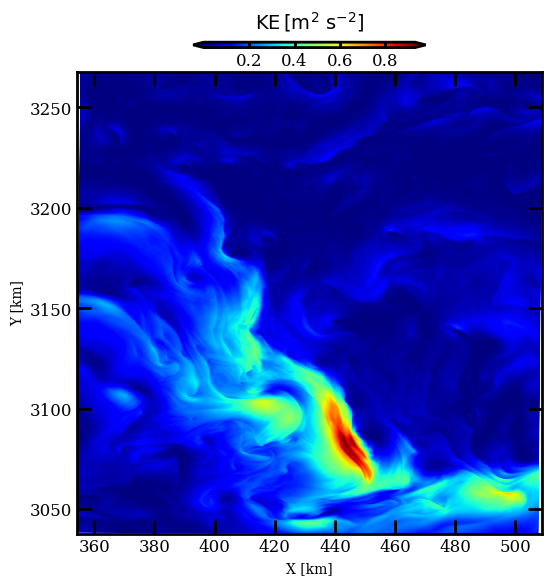

In [4]:
fig,ax = plt.subplots(figsize=(6,6))
im = ax.pcolormesh(X/1.0e3,Y/1.0e3,0.5*(u**2 + v**2),cmap='jet',shading='gouraud')

pos1cb = ax.get_position()
cbar_ax = fig.add_axes([pos1cb.x0+pos1cb.width/4., pos1cb.y0+0.04+pos1cb.height , pos1cb.width/2. , 0.009])
cbar = fig.colorbar(im, cax=cbar_ax,orientation='horizontal',\
                            extend='both',ticks=np.arange(0,1,0.2))
cbar.set_label(r'$ {\rm KE \,  [} {\rm m^{2}~} {\rm s^{-2}]}$',fontsize= fontsize + 2 ,labelpad=10)
cbar.ax.tick_params(labelsize=fontsize,direction='in',width=linewidth,size=4)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('both')
cbar.outline.set_linewidth( linewidth )
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth( linewidth )
    ax.spines[axis].set_color('k')
ax.tick_params(direction='in',bottom='on',top='on',left='on',right='on')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')

In [5]:
gc.collect()

2449

# Format Dataset

In [6]:
# Create the xarray dataset
ds = xr.Dataset({
    'u': (['y', 'x'], u),
    'v': (['y', 'x'], v),
    'adv_u':(['y', 'x'], adv_u),
    'adv_v':(['y', 'x'], adv_v),
    'temperature':(['y', 'x'], temp),
    'vort':(['y', 'x'], vort),
    'adv_vort':(['y', 'x'], adv_vort),


}, coords={
    'x': (['y', 'x'], X),
    'y': (['y', 'x'], Y)
})



In [7]:
ds

<xarray.Dataset> Size: 69MB
Dimensions:      (y: 1537, x: 1025)
Coordinates:
    x            (y, x) float64 13MB 3.542e+05 3.544e+05 ... 5.086e+05 5.088e+05
    y            (y, x) float64 13MB 3.039e+06 3.039e+06 ... 3.267e+06 3.267e+06
Data variables:
    u            (y, x) float32 6MB -0.3907 -0.4025 -0.4012 ... 0.01855 0.01787
    v            (y, x) float32 6MB 0.08256 0.09225 0.1009 ... 0.0189 0.01809
    adv_u        (y, x) float32 6MB 1.877e-05 1.042e-05 ... 2.56e-07 9.305e-08
    adv_v        (y, x) float32 6MB -1.566e-05 -1.693e-05 ... -3.382e-07
    temperature  (y, x) float32 6MB 25.06 25.06 25.06 ... 20.97 20.97 20.97
    vort         (y, x) float32 6MB 9.174e-05 9.375e-05 ... 7.981e-05 8.993e-05
    adv_vort     (y, x) float32 6MB -6.696e-09 -4.602e-09 ... 7.135e-10

# Calculate 2D Longitudinal SF, $\epsilon=0.05$

In [8]:
%%time

bins = {
    'x': np.logspace(np.log10(150.), np.log10(153.6e3), 12),
    'y': np.logspace(np.log10(150.), np.log10(153.6e3), 12)
}
sf_result = psf.bin_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=180,
    convergence_eps=0.05,
    n_jobs=-1,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING BIN_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 113/121
Marked 8 bins as converged (low_density)
Marked 98 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 15 unconverged bins
Grouped unconverged bins into 1 groups

Processing 15 bins with step size 180 in density quartile 0
  Bin (0,8) CONVERGED with std 0.042649
  Bin (3,8) CONVERGED with std 0.043761
  Bin (3,10) CONVERGED with std 0.048492
  Bin (4,8) CONVERGED with std 0.

In [9]:
gc.collect()

40

# Plot 2D Longitudial SF (structure function, standard error, number of bootstrap samples to reach convergence)

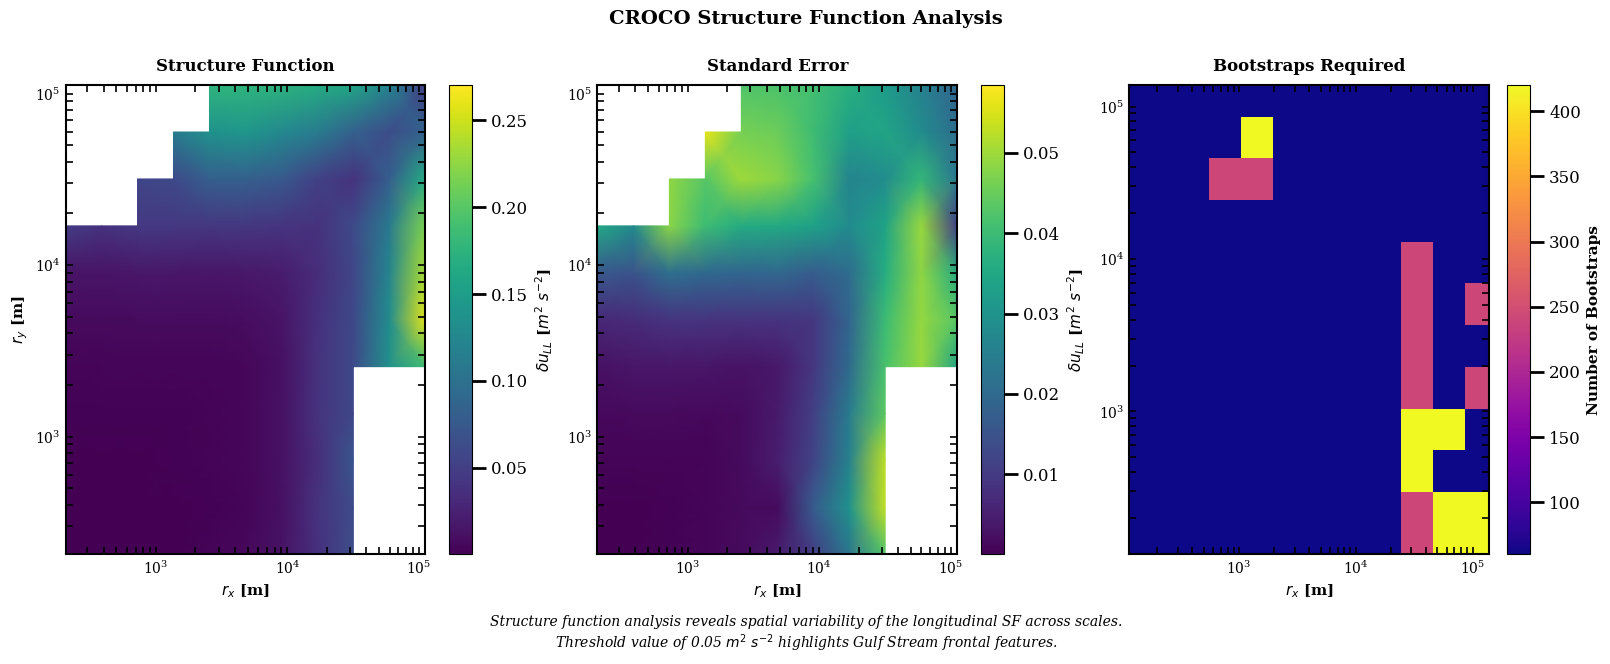

In [10]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', r'$\delta u_{LL}$ [$m^{2}~s^{-2}$]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf, sf_result.sf_std, sf_result.nbootstraps]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0 or i == 1:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap)
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
    

    
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('CROCO Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial variability of the longitudinal SF across scales.\n'
         'Threshold value of 0.05 $m^{2}~s^{-2}$ highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

In [11]:
gc.collect()

3020

# Calculate ISOTROPIC Longitudinal and Transverse SF, $\epsilon=0.05$

In [12]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)
bins = {
    'r': bin_r,
}
iso_sf_lon = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.05,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky'
)

iso_sf_trans = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='transverse',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.05,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 11/11
Marked 10 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 1 unconverged bins
Grouped unconverged bins into 1 groups

Processing 1 bins with step size 40 in density quartile 0
  Bin 9 CONVERGED with std 0.042660
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 points): 11
  Converged bins: 11
  Unconverged b

In [14]:
gc.collect()

0

# Plot Isotropic Longitudinal and Transverse SF

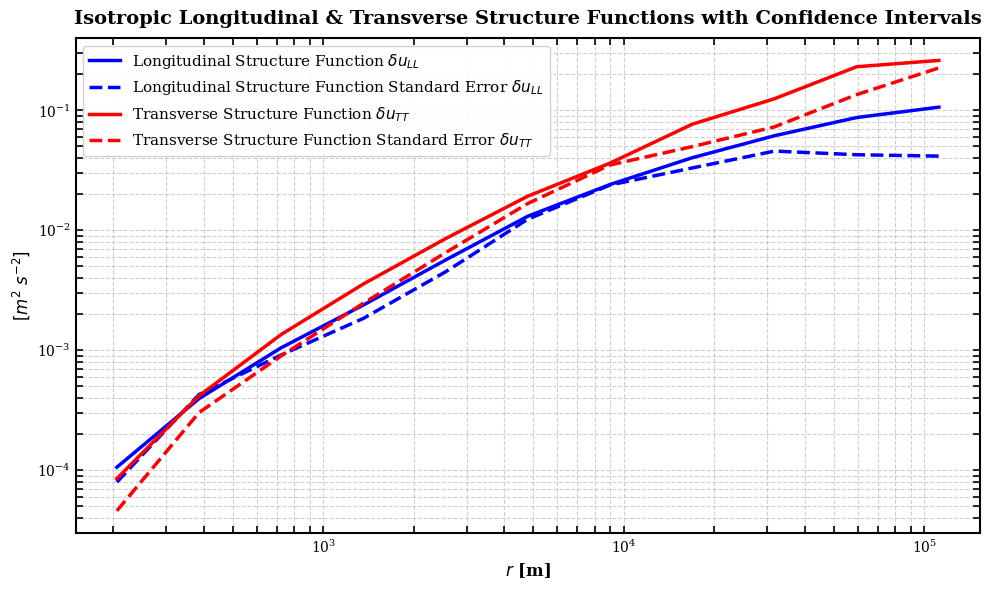

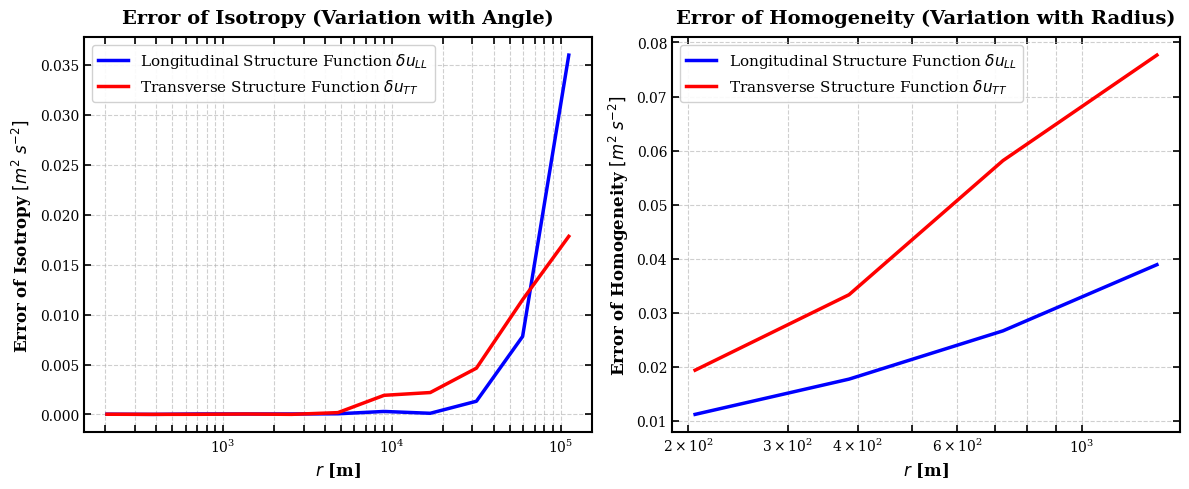

In [15]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
# Add longitudinal structure function with error bars
plt.loglog(iso_sf_lon.r, iso_sf_lon.sf, 'b-', linewidth=2.5, label='Longitudinal Structure Function'+' '+'$\delta u_{LL}$')
plt.loglog(iso_sf_lon.r,iso_sf_lon['std'], 'b--',linewidth=2.5, label='Longitudinal Structure Function Standard Error'+' '+'$\delta u_{LL}$')
# Add transverse structure function with error bars
plt.loglog(iso_sf_trans.r, iso_sf_trans.sf, 'r-', linewidth=2.5, label='Transverse Structure Function'+' '+'$\delta u_{TT}$')
plt.loglog(iso_sf_trans.r,iso_sf_trans['std'], 'r--',linewidth=2.5, label='Transverse Structure Function Standard Error'+' '+'$\delta u_{TT}$')


# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Longitudinal & Transverse Structure Functions with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.yscale('log')
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_lon.r, iso_sf_lon.error_isotropy, 'b-', linewidth=2.5,label='Longitudinal Structure Function'+' '+'$\delta u_{LL}$')
plt.plot(iso_sf_trans.r, iso_sf_trans.error_isotropy, 'r-', linewidth=2.5,label='Transverse Structure Function'+' '+'$\delta u_{TT}$')

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_lon.r_subset, iso_sf_lon.error_homogeneity, 'b-', linewidth=2.5,label='Longitudinal Structure Function'+' '+'$\delta u_{LL}$')
plt.plot(iso_sf_trans.r_subset, iso_sf_trans.error_homogeneity, 'r-', linewidth=2.5,label='Transverse Structure Function'+' '+'$\delta u_{TT}$')
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

# Calculate Isotropic advective-SF $\delta u.\delta ADV$

In [16]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)

bins = {
    'r': bin_r,
}
iso_sf_adv = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v","adv_u","adv_v"],
    order=1,
    bins=bins,
    fun='advective',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-8,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky'
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 11/11
Marked 1 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 10 unconverged bins
Grouped unconverged bins into 2 groups

Processing 5 bins with step size 40 in density quartile 1

Processing 5 bins with step size 40 in density quartile 0

Iteration 2 - 10 unconverged bins
Grouped unconverged bins into 2 groups

Processing 5 bins with step size 40 in densit

# Plot Isotropic advective-SF $\delta u.\delta ADV$

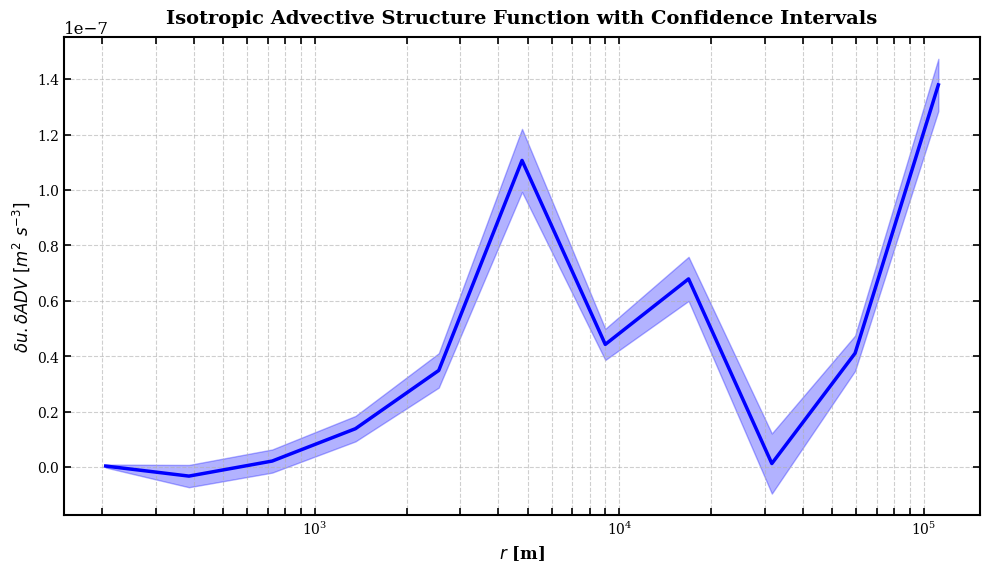

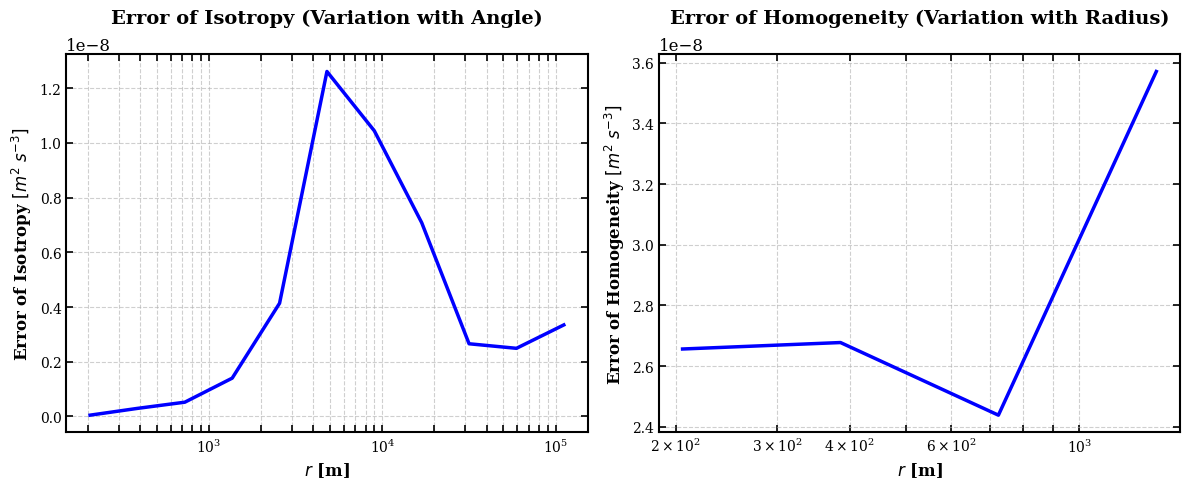

CPU times: user 761 ms, sys: 4.75 ms, total: 766 ms
Wall time: 765 ms


In [17]:
%%time

# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_adv.r, iso_sf_adv.sf, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_adv.r, 
                iso_sf_adv.ci_lower, 
                iso_sf_adv.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta u.\delta ADV~[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Advective Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_adv.r, iso_sf_adv.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_adv.r_subset, iso_sf_adv.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m^{2}~s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

# Calculate Isotropic $\delta \omega_{z} * \delta ADV_{\omega_{z}}$

In [18]:
%%time
bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)

bins = {
    'r': bin_r,
}
iso_sf_adv = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["vort","adv_vort"],
    order=(1,1),
    bins=bins,
    fun='scalar_scalar',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-14,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: scalar_scalar
Variables: ['vort', 'adv_vort'], Order: (1, 1)


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 11/11
Marked 1 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 10 unconverged bins
Grouped unconverged bins into 2 groups

Processing 5 bins with step size 40 in density quartile 1

Processing 5 bins with step size 40 in density quartile 0

Iteration 2 - 10 unconverged bins
Grouped unconverged bins into 2 groups

Processing 5 bins with step size 40 in densi

# Plot Isotropic $\delta \omega_{z} * \delta ADV_{\omega_{z}}$

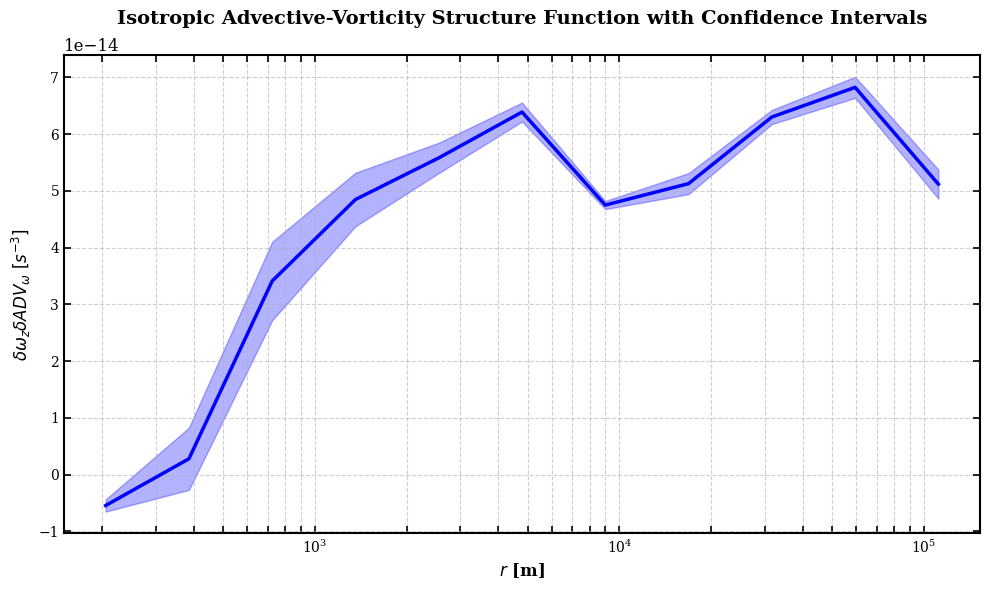

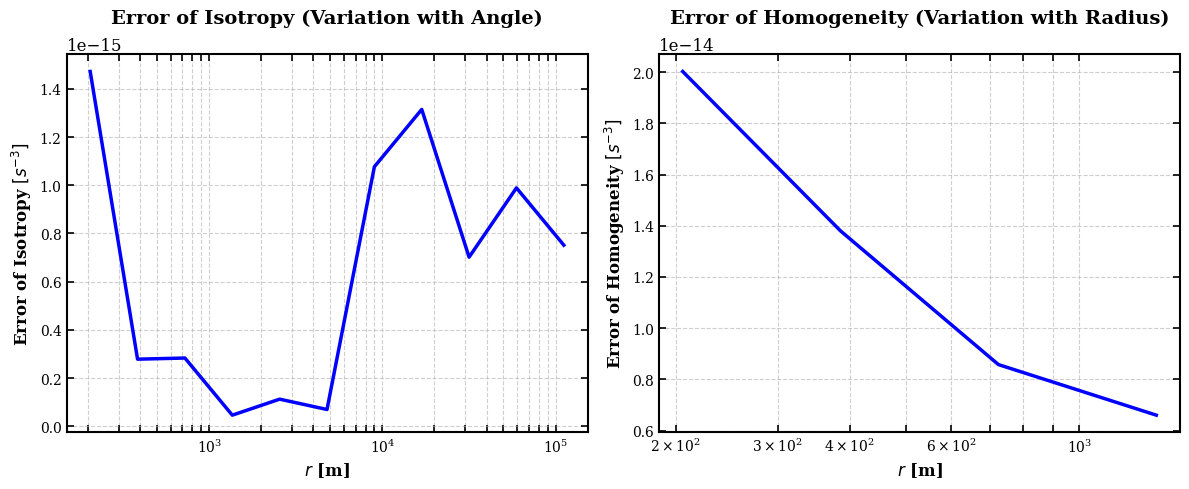

In [19]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_adv.r, iso_sf_adv.sf, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_adv.r, 
                iso_sf_adv.ci_lower, 
                iso_sf_adv.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta \omega_{z}\delta ADV_{\omega}~[s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Advective-Vorticity Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_adv.r, iso_sf_adv.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_adv.r_subset, iso_sf_adv.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[s^{-3}]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()

# Calculate Isotropic $\delta u \delta T$

In [20]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(155.0e3), 20)
bins = {
    'r': bin_r,
}
iso_sf_scalar = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","temperature"],
    order=(1,1),
    bins=bins,
    fun='scalar_scalar',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.01,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky'
    
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: scalar_scalar
Variables: ['u', 'temperature'], Order: (1, 1)


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 19/19
Marked 8 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 11 unconverged bins
Grouped unconverged bins into 1 groups

Processing 11 bins with step size 40 in density quartile 0

Iteration 2 - 11 unconverged bins
Grouped unconverged bins into 1 groups

Processing 11 bins with step size 40 in density quartile 0
  Bin 8 CONVERGED with std 0.009612

Iterat

# Plot Isotropic $\delta u \delta T$

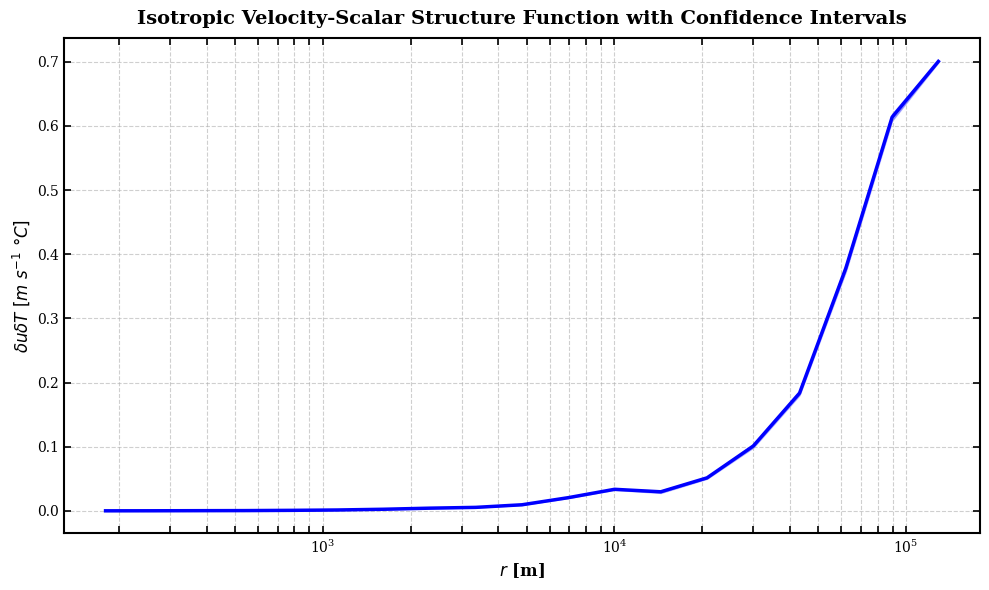

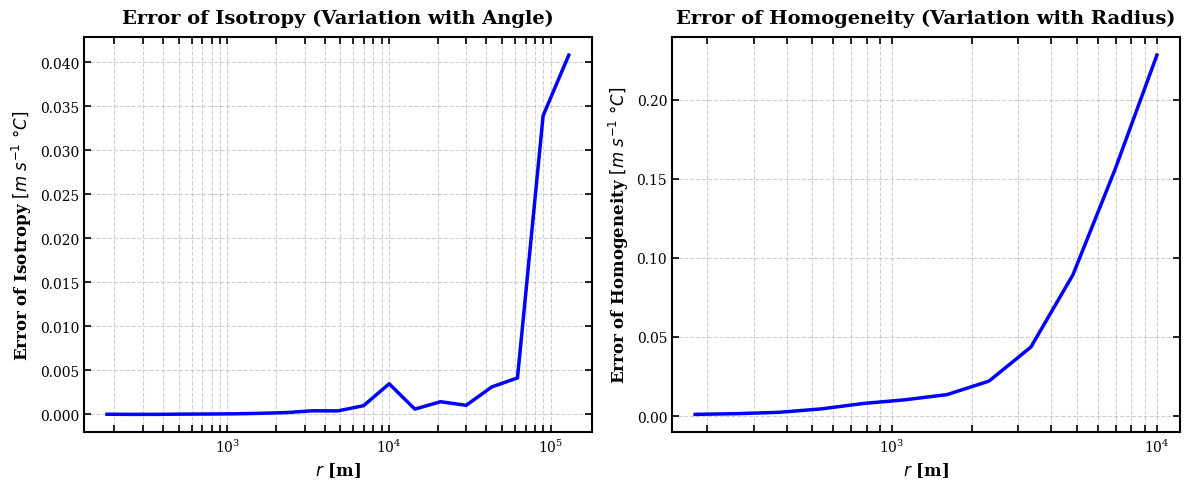

In [21]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf_scalar.r, iso_sf_scalar.sf, 'b-', linewidth=2.5)

plt.fill_between(iso_sf_scalar.r, 
                iso_sf_scalar.ci_lower, 
                iso_sf_scalar.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta u \delta T~[m~s^{-1}~°C]$', fontsize=12, fontweight='bold')
plt.title('Isotropic Velocity-Scalar Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf_scalar.r, iso_sf_scalar.error_isotropy, 'b-', linewidth=2.5)

plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy'+' '+r'$[m~s^{-1}~°C]$', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf_scalar.r_subset, iso_sf_scalar.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity'+' '+r'$[m~s^{-1}~°C]$', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

plt.show()